<a href="https://colab.research.google.com/github/Val095/InteligenciaArtificial_II/blob/main/MNIST_Reconocimiento_Numeros.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Introducción

MNIST es uno de los datasets más utilizados para aprender clasificación y reconocimiento de imágenes. Contiene imágenes de números escritos a mano, desde el 0 hasta el 9.

En este ejercicio se construirá una red neuronal sencilla con TensorFlow/Keras para aprender a reconocer esos números. Además de la exactitud, se utilizarán matriz de confusión, Precision, Recall, F1 Score, curva ROC y AUC para evaluar el rendimiento.

> **Importante:** las métricas finales se calculan directamente al ejecutar el notebook. No se escriben resultados inventados.


# 2. Objetivo

El objetivo es entrenar un modelo de Machine Learning capaz de clasificar correctamente imágenes de números escritos a mano del 0 al 9, analizar su rendimiento y dejar el proyecto preparado para publicarlo en GitHub.


# 3. Importación de librerías

Se utilizan únicamente las librerías principales necesarias para cargar MNIST, trabajar con los datos, entrenar la red neuronal, calcular métricas y generar visualizaciones.


In [1]:
import numpy as np  # Importo NumPy para trabajar con arreglos y operaciones numéricas.
import pandas as pd  # Importo Pandas para construir y mostrar tablas de resultados.
import matplotlib.pyplot as plt  # Importo Matplotlib para crear las gráficas.
import tensorflow as tf  # Importo TensorFlow para construir y entrenar la red neuronal.
from tensorflow import keras  # Importo Keras, la API de alto nivel de TensorFlow.
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, accuracy_score, precision_score, recall_score, f1_score  # Importo las métricas necesarias para evaluar el modelo.
from sklearn.preprocessing import label_binarize  # Importo esta función para convertir las etiquetas al formato necesario para ROC multiclase.
from IPython.display import display  # Importo display para mostrar las tablas de Pandas de forma más clara en Colab.

np.random.seed(42)  # Fijo una semilla para que algunas operaciones aleatorias sean reproducibles.
tf.random.set_seed(42)  # Fijo la semilla de TensorFlow para favorecer resultados reproducibles.


# 4. Carga del dataset MNIST

MNIST significa **Modified National Institute of Standards and Technology**. Está formado por imágenes de dígitos escritos a mano.

Cada imagen tiene un tamaño de **28 × 28 píxeles** y está asociada a una etiqueta entre 0 y 9. El conjunto clásico contiene aproximadamente **60.000 imágenes de entrenamiento y 10.000 de prueba**.

Keras puede descargar MNIST directamente desde su repositorio de datasets cuando se ejecuta por primera vez.


In [2]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()  # Descargo y separo MNIST en imágenes y etiquetas de entrenamiento y prueba.
print("Forma de x_train:", x_train.shape)  # Muestro la cantidad y dimensiones de las imágenes de entrenamiento.
print("Forma de y_train:", y_train.shape)  # Muestro la cantidad de etiquetas de entrenamiento.
print("Forma de x_test:", x_test.shape)  # Muestro la cantidad y dimensiones de las imágenes de prueba.
print("Forma de y_test:", y_test.shape)  # Muestro la cantidad de etiquetas de prueba.


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Forma de x_train: (60000, 28, 28)
Forma de y_train: (60000,)
Forma de x_test: (10000, 28, 28)
Forma de y_test: (10000,)


# 5. Exploración de los datos

Antes de entrenar el modelo se revisan las dimensiones, los valores de los píxeles y algunas imágenes. Esto permite entender qué información recibe la red neuronal.


In [3]:
print("Valor mínimo de los píxeles:", x_train.min())  # Compruebo el valor mínimo presente en las imágenes.
print("Valor máximo de los píxeles:", x_train.max())  # Compruebo el valor máximo presente en las imágenes.
print("Cantidad de valores faltantes en entrenamiento:", np.isnan(x_train).sum())  # Compruebo si existen valores faltantes en las imágenes.
print("Cantidad de valores faltantes en prueba:", np.isnan(x_test).sum())  # Compruebo si existen valores faltantes en las imágenes de prueba.
print("Clases presentes:", np.unique(y_train))  # Muestro las etiquetas diferentes que existen en el entrenamiento.


Valor mínimo de los píxeles: 0
Valor máximo de los píxeles: 255
Cantidad de valores faltantes en entrenamiento: 0
Cantidad de valores faltantes en prueba: 0
Clases presentes: [0 1 2 3 4 5 6 7 8 9]


# 6. Preprocesamiento

Los píxeles de MNIST tienen valores entre 0 y 255. Se normalizan dividiéndolos entre 255 para llevarlos aproximadamente al rango 0–1. Esto facilita el entrenamiento de la red neuronal.

La red utilizada recibe directamente las imágenes de 28 × 28 píxeles mediante una capa `Flatten`, por lo que no es necesario convertirlas manualmente a un vector antes de entregarlas al modelo.


In [4]:
x_train = x_train.astype("float32") / 255.0  # Convierto los píxeles a decimal y los normalizo entre 0 y 1.
x_test = x_test.astype("float32") / 255.0  # Aplico la misma normalización a las imágenes de prueba.
print("Nuevo valor mínimo:", x_train.min())  # Compruebo el mínimo después de normalizar.
print("Nuevo valor máximo:", x_train.max())  # Compruebo el máximo después de normalizar.


Nuevo valor mínimo: 0.0
Nuevo valor máximo: 1.0


# 7. Visualización de imágenes

Se muestran varias imágenes junto con sus etiquetas reales. Cada imagen representa un dígito escrito a mano y cada etiqueta indica qué número representa.


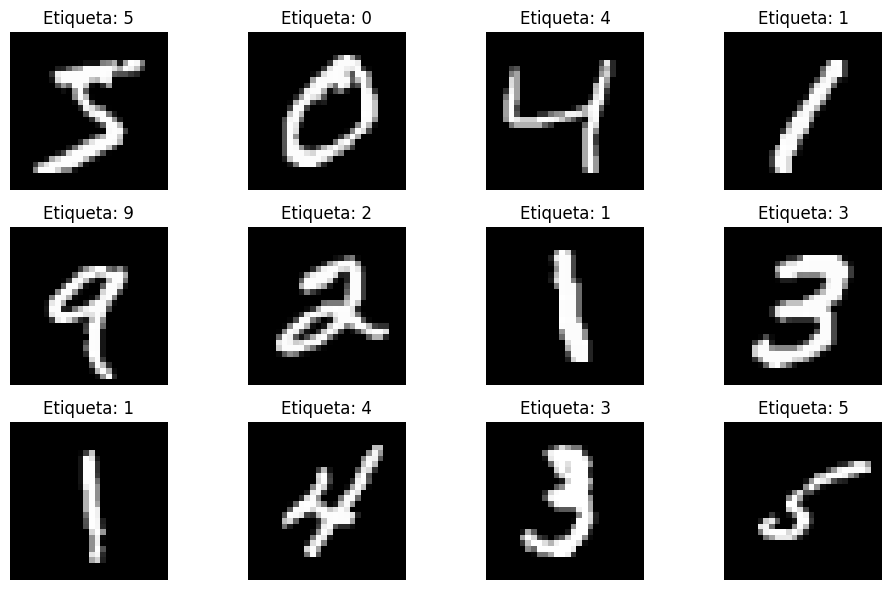

In [5]:
plt.figure(figsize=(10, 6))  # Creo una figura con un tamaño adecuado para mostrar varias imágenes.
for i in range(12):  # Recorro las primeras doce imágenes del conjunto de entrenamiento.
    plt.subplot(3, 4, i + 1)  # Creo una posición dentro de una cuadrícula de tres filas y cuatro columnas.
    plt.imshow(x_train[i], cmap="gray")  # Muestro la imagen en escala de grises.
    plt.title(f"Etiqueta: {y_train[i]}")  # Escribo la etiqueta real encima de la imagen.
    plt.axis("off")  # Oculto los ejes para que la imagen sea más fácil de observar.
plt.tight_layout()  # Ajusto automáticamente los espacios entre las imágenes.
plt.show()  # Muestro la figura.


# 8. Construcción del modelo

Se utiliza una red neuronal artificial sencilla:

- `Flatten`: convierte cada imagen 28 × 28 en un vector de 784 valores.
- `Dense(128, activation="relu")`: aprende patrones mediante 128 neuronas.
- `Dropout(0.2)`: desactiva aleatoriamente una parte de las neuronas durante el entrenamiento para ayudar a reducir sobreajuste.
- `Dense(10, activation="softmax")`: produce una probabilidad para cada uno de los diez números.

Se utiliza `sparse_categorical_crossentropy` porque las etiquetas están representadas directamente como números enteros de 0 a 9. El optimizador Adam permite ajustar los pesos de la red durante el entrenamiento.


In [6]:
model = keras.Sequential()  # Creo un modelo secuencial donde las capas se organizan una después de otra.
model.add(keras.layers.Flatten(input_shape=(28, 28)))  # Convierto cada imagen de 28 por 28 píxeles en un vector de 784 valores.
model.add(keras.layers.Dense(128, activation="relu"))  # Agrego una capa de 128 neuronas que aprende patrones usando ReLU.
model.add(keras.layers.Dropout(0.2))  # Desactivo aleatoriamente el 20 por ciento de las neuronas durante el entrenamiento para reducir sobreajuste.
model.add(keras.layers.Dense(10, activation="softmax"))  # Agrego diez salidas, una para cada clase del 0 al 9, usando probabilidades.
model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])  # Configuro Adam, la función de pérdida y la métrica de exactitud.
model.summary()  # Muestro la estructura y cantidad de parámetros del modelo.


/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

# 9. Entrenamiento

Se entrenará durante 10 épocas con lotes de 128 imágenes. El 10 % de los datos de entrenamiento se utilizará como validación.

La validación permite observar cómo funciona el modelo con datos que no utiliza para actualizar directamente sus pesos durante cada época.


In [7]:
history = model.fit(x_train, y_train, epochs=10, batch_size=128, validation_split=0.1, verbose=1)  # Entreno el modelo durante diez épocas y guardo el historial.


Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.8777 - loss: 0.4251 - val_accuracy: 0.9558 - val_loss: 0.1706
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9407 - loss: 0.2045 - val_accuracy: 0.9652 - val_loss: 0.1242
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9546 - loss: 0.1541 - val_accuracy: 0.9700 - val_loss: 0.1048
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9630 - loss: 0.1264 - val_accuracy: 0.9733 - val_loss: 0.0944
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9677 - loss: 0.1068 - val_accuracy: 0.9752 - val_loss: 0.0863
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9719 - loss: 0.0928 - val_accuracy: 0.9777 - val_loss: 0.0780
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9746 - loss: 0.0832 - val_accuracy: 0.9788 - val_loss: 0.0733
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9768 - loss: 0.0749 - val_accuracy: 0

## Evolución del Accuracy

La siguiente gráfica compara el Accuracy de entrenamiento y validación. Si ambas curvas mantienen valores altos y relativamente cercanos, el modelo está aprendiendo correctamente sin una separación excesiva entre entrenamiento y validación.


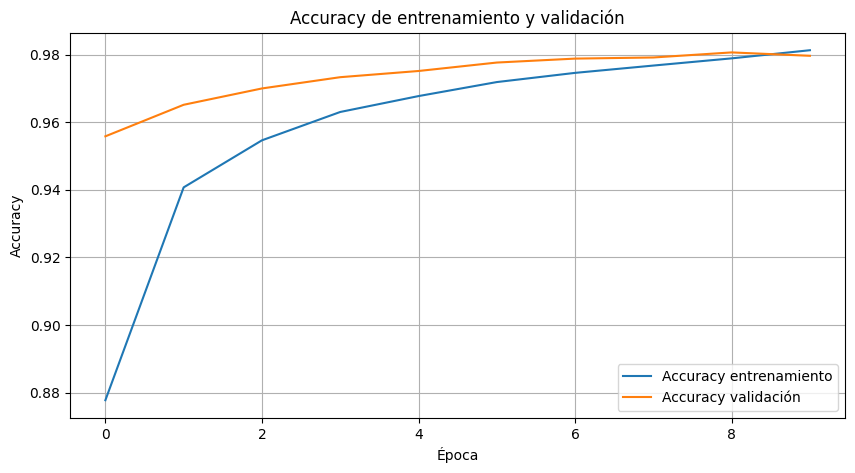

In [8]:
plt.figure(figsize=(10, 5))  # Creo una figura para representar la evolución del Accuracy.
plt.plot(history.history["accuracy"], label="Accuracy entrenamiento")  # Grafico el Accuracy obtenido durante el entrenamiento.
plt.plot(history.history["val_accuracy"], label="Accuracy validación")  # Grafico el Accuracy obtenido sobre los datos de validación.
plt.xlabel("Época")  # Etiqueto el eje horizontal con el número de época.
plt.ylabel("Accuracy")  # Etiqueto el eje vertical con la exactitud.
plt.title("Accuracy de entrenamiento y validación")  # Coloco un título descriptivo.
plt.legend()  # Muestro la leyenda para distinguir las dos curvas.
plt.grid(True)  # Agrego una cuadrícula para facilitar la lectura.
plt.show()  # Muestro la gráfica.


### Interpretación

La interpretación definitiva debe hacerse observando la gráfica generada. Una validación cercana al entrenamiento indica un comportamiento consistente; una separación grande y creciente puede ser señal de sobreajuste.


## Evolución del Loss

La pérdida (`loss`) muestra qué tan diferentes son las predicciones del modelo respecto de las etiquetas reales. Durante un entrenamiento adecuado, normalmente se espera que disminuya.


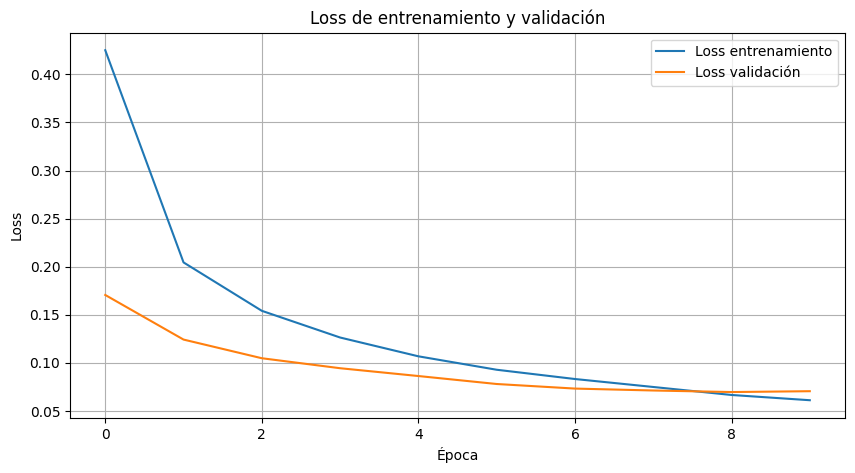

In [9]:
plt.figure(figsize=(10, 5))  # Creo una figura para representar la evolución de la pérdida.
plt.plot(history.history["loss"], label="Loss entrenamiento")  # Grafico la pérdida del conjunto de entrenamiento.
plt.plot(history.history["val_loss"], label="Loss validación")  # Grafico la pérdida del conjunto de validación.
plt.xlabel("Época")  # Etiqueto el eje horizontal con el número de época.
plt.ylabel("Loss")  # Etiqueto el eje vertical con la pérdida.
plt.title("Loss de entrenamiento y validación")  # Coloco un título descriptivo.
plt.legend()  # Muestro la leyenda de las curvas.
plt.grid(True)  # Agrego una cuadrícula para facilitar la lectura.
plt.show()  # Muestro la gráfica.


### Interpretación

La pérdida debería mostrar una tendencia general descendente. La lectura final debe basarse en la curva que produzca la ejecución del notebook.


# 10. Evaluación

Se evalúa el modelo utilizando el conjunto de prueba, que no se utilizó para entrenarlo.


In [10]:
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)  # Evalúo el modelo con las imágenes de prueba.
print("Loss en prueba:", test_loss)  # Muestro la pérdida obtenida sobre el conjunto de prueba.
print("Accuracy en prueba:", test_accuracy)  # Muestro la exactitud obtenida sobre el conjunto de prueba.


Loss en prueba: 0.07117631286382675
Accuracy en prueba: 0.9782000184059143


# 11. Predicciones de números

El modelo genera una probabilidad para cada una de las diez clases. Se selecciona como predicción la clase con mayor probabilidad.


In [11]:
probabilidades = model.predict(x_test, verbose=0)  # Obtengo las probabilidades de las diez clases para cada imagen de prueba.
y_pred = np.argmax(probabilidades, axis=1)  # Selecciono la clase con mayor probabilidad para cada imagen.


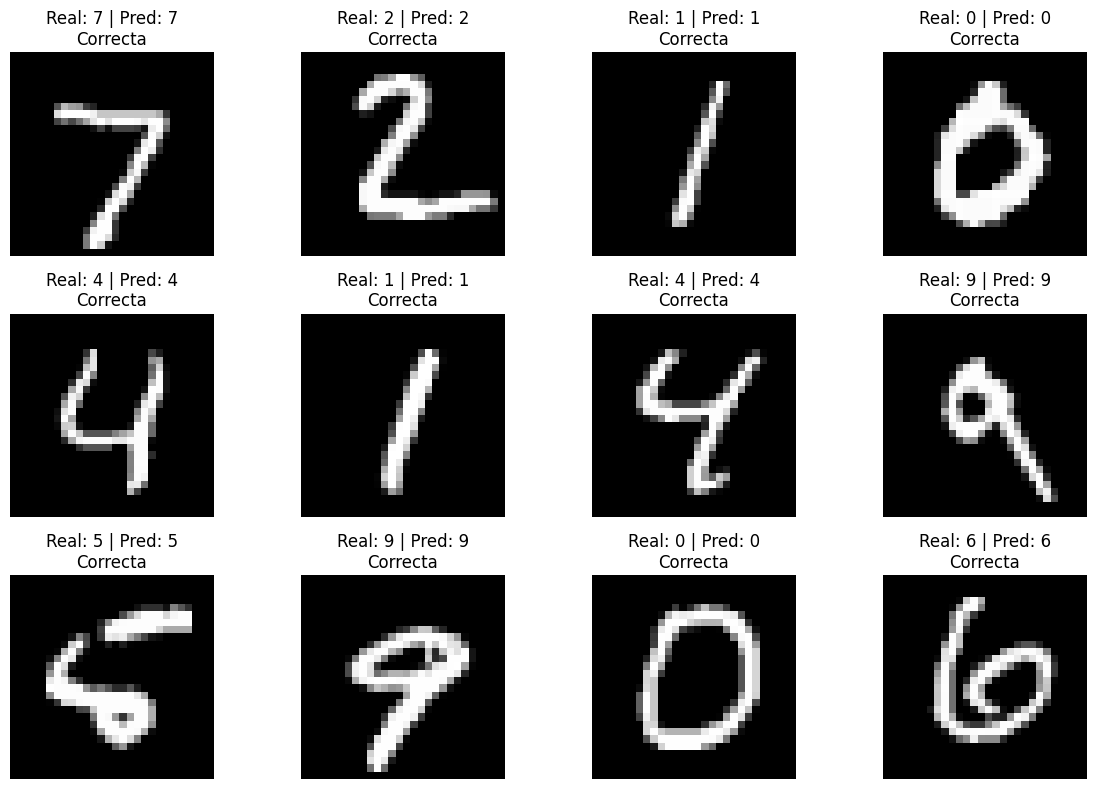

In [12]:
plt.figure(figsize=(12, 8))  # Creo una figura para visualizar varias predicciones.
for i in range(12):  # Recorro doce imágenes del conjunto de prueba.
    plt.subplot(3, 4, i + 1)  # Creo una posición dentro de la cuadrícula.
    plt.imshow(x_test[i], cmap="gray")  # Muestro la imagen de prueba.
    resultado = "Correcta" if y_test[i] == y_pred[i] else "Incorrecta"  # Comparo la etiqueta real con la predicción.
    plt.title(f"Real: {y_test[i]} | Pred: {y_pred[i]}\n{resultado}")  # Muestro el valor real, el predicho y el resultado.
    plt.axis("off")  # Oculto los ejes.
plt.tight_layout()  # Ajusto los espacios de la figura.
plt.show()  # Muestro las predicciones.


## Ejemplo de una sola imagen

A continuación se toma una sola imagen de MNIST y se muestra la probabilidad que el modelo asigna a cada clase.


Número real: 7
Número predicho: 7
Probabilidad de la clase predicha: 0.9991844


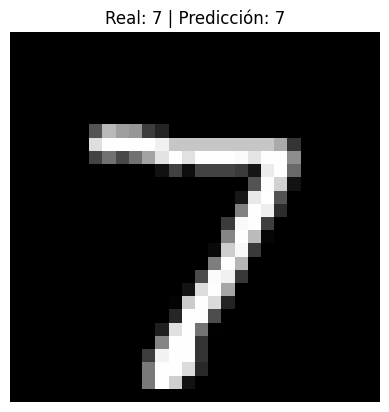

In [13]:
indice = 0  # Selecciono la primera imagen del conjunto de prueba.
imagen = x_test[indice]  # Guardo la imagen seleccionada.
prediccion = y_pred[indice]  # Obtengo la clase predicha para esa imagen.
print("Número real:", y_test[indice])  # Muestro la etiqueta real.
print("Número predicho:", prediccion)  # Muestro el número identificado por el modelo.
print("Probabilidad de la clase predicha:", probabilidades[indice, prediccion])  # Muestro la probabilidad asignada a la clase predicha.
plt.imshow(imagen, cmap="gray")  # Muestro la imagen seleccionada.
plt.title(f"Real: {y_test[indice]} | Predicción: {prediccion}")  # Coloco un título con el resultado.
plt.axis("off")  # Oculto los ejes.
plt.show()  # Muestro la imagen.


# 12. Matriz de confusión

La matriz de confusión permite comparar las clases reales con las clases predichas.

- **Filas:** representan la clase real.
- **Columnas:** representan la clase predicha.
- **Diagonal:** contiene las predicciones correctas.
- **Fuera de la diagonal:** contiene errores de clasificación.


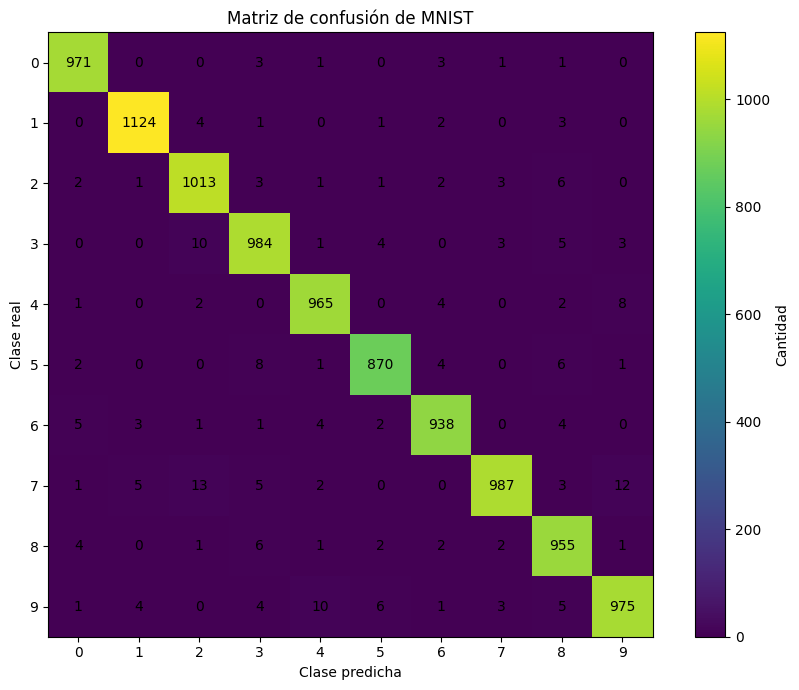

In [14]:
cm = confusion_matrix(y_test, y_pred)  # Calculo la matriz de confusión comparando las etiquetas reales y las predicciones.
plt.figure(figsize=(9, 7))  # Creo una figura para visualizar la matriz.
plt.imshow(cm)  # Muestro la matriz como una imagen.
plt.title("Matriz de confusión de MNIST")  # Coloco un título descriptivo.
plt.xlabel("Clase predicha")  # Etiqueto el eje horizontal.
plt.ylabel("Clase real")  # Etiqueto el eje vertical.
plt.xticks(range(10), range(10))  # Coloco las clases del 0 al 9 en el eje horizontal.
plt.yticks(range(10), range(10))  # Coloco las clases del 0 al 9 en el eje vertical.
plt.colorbar(label="Cantidad")  # Agrego una barra que representa la cantidad de ejemplos.
for fila in range(10):  # Recorro cada fila de la matriz.
    for columna in range(10):  # Recorro cada columna de la matriz.
        plt.text(columna, fila, cm[fila, columna], ha="center", va="center")  # Escribo el valor de cada celda sobre la gráfica.
plt.tight_layout()  # Ajusto el espacio de la gráfica.
plt.show()  # Muestro la matriz.


In [15]:
errores_por_clase = cm.sum(axis=1) - np.diag(cm)  # Calculo cuántos errores tuvo cada clase excluyendo la diagonal.
clase_mas_confundida = int(np.argmax(errores_por_clase))  # Identifico la clase real que acumuló más errores.
print("Clase real con más errores:", clase_mas_confundida)  # Muestro la clase que tuvo más errores totales.
print("Cantidad de errores:", errores_por_clase[clase_mas_confundida])  # Muestro la cantidad de errores de esa clase.


Clase real con más errores: 7
Cantidad de errores: 41


# 13. Curva ROC y AUC

MNIST es un problema de clasificación multiclase. Para aplicar ROC se utiliza el enfoque **One-vs-Rest (OvR)**: cada número se considera como la clase positiva y los otros nueve números se consideran como la clase negativa.

El modelo entrega probabilidades para cada clase. Con esas probabilidades se calculan FPR (False Positive Rate), TPR (True Positive Rate) y AUC (Area Under the Curve).


In [16]:
y_test_bin = label_binarize(y_test, classes=np.arange(10))  # Convierto las etiquetas reales a formato binario para aplicar ROC One-vs-Rest.
fpr = {}  # Creo un diccionario donde guardaré la tasa de falsos positivos de cada clase.
tpr = {}  # Creo un diccionario donde guardaré la tasa de verdaderos positivos de cada clase.
thresholds = {}  # Creo un diccionario donde guardaré los umbrales de cada clase.
roc_auc = {}  # Creo un diccionario donde guardaré el AUC de cada clase.
for clase in range(10):  # Calculo una curva ROC independiente para cada número.
    fpr[clase], tpr[clase], thresholds[clase] = roc_curve(y_test_bin[:, clase], probabilidades[:, clase])  # Calculo FPR, TPR y umbrales usando la probabilidad de la clase actual.
    roc_auc[clase] = auc(fpr[clase], tpr[clase])  # Calculo el área bajo la curva ROC de la clase actual.


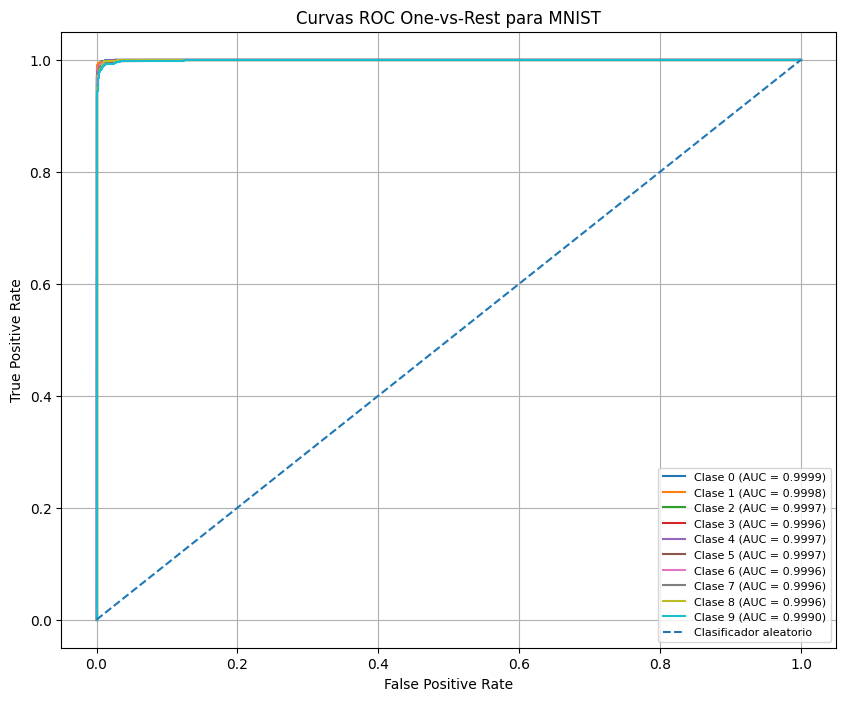

In [17]:
plt.figure(figsize=(10, 8))  # Creo una figura para las diez curvas ROC.
for clase in range(10):  # Recorro las diez clases.
    plt.plot(fpr[clase], tpr[clase], label=f"Clase {clase} (AUC = {roc_auc[clase]:.4f})")  # Dibujo la curva ROC y muestro su AUC.
plt.plot([0, 1], [0, 1], linestyle="--", label="Clasificador aleatorio")  # Dibujo la referencia de un clasificador aleatorio.
plt.xlabel("False Positive Rate")  # Etiqueto el eje horizontal.
plt.ylabel("True Positive Rate")  # Etiqueto el eje vertical.
plt.title("Curvas ROC One-vs-Rest para MNIST")  # Coloco un título descriptivo.
plt.legend(loc="lower right", fontsize=8)  # Muestro la leyenda con las diez clases.
plt.grid(True)  # Agrego una cuadrícula.
plt.show()  # Muestro las curvas.


## Tabla ROC/AUC

Esta tabla se genera automáticamente con los AUC calculados. Por tanto, los valores cambian si cambia el entrenamiento o el modelo.


In [18]:
tabla_roc_auc = pd.DataFrame({"Clase": np.arange(10), "AUC": [roc_auc[clase] for clase in range(10)]})  # Construyo una tabla con el AUC de cada clase.
display(tabla_roc_auc)  # Muestro la tabla de AUC en Colab.


,Clase,AUC
0,0,0.999899
1,1,0.999756
2,2,0.999675
3,3,0.999629
4,4,0.999730
5,5,0.999703
6,6,0.999575
7,7,0.999580
8,8,0.999632
9,9,0.999040


### Tabla adicional de FPR, TPR y umbral

La curva ROC contiene varios puntos. Se construye una tabla completa con esos valores para cada clase. Puede tener muchas filas porque cada umbral genera un punto.


In [19]:
filas_roc = []  # Creo una lista vacía para almacenar los puntos de todas las curvas ROC.
for clase in range(10):  # Recorro cada una de las diez clases.
    for i in range(len(fpr[clase])):  # Recorro todos los puntos de la curva de la clase actual.
        filas_roc.append({"Clase": clase, "FPR": fpr[clase][i], "TPR": tpr[clase][i], "Umbral": thresholds[clase][i]})  # Guardo clase, FPR, TPR y umbral de cada punto.
tabla_roc_detallada = pd.DataFrame(filas_roc)  # Convierto la lista de puntos en una tabla de Pandas.
display(tabla_roc_detallada)  # Muestro la tabla completa de la curva ROC.


,Clase,FPR,TPR,Umbral
0,0,0.000000,0.000000,inf
1,0,0.000000,0.012245,9.999999e-01
2,0,0.000000,0.029592,9.999998e-01
3,0,0.000000,0.043878,9.999997e-01
4,0,0.000000,0.057143,9.999996e-01
...,...,...,...,...
1663,9,0.123790,0.998018,5.439444e-04
1664,9,0.123790,0.999009,5.436562e-04
1665,9,0.358581,0.999009,1.248124e-05
1666,9,0.358581,1.000000,1.244532e-05


# 14. Tabla Precision, Recall y F1 Score

El **Precision** indica qué proporción de las predicciones realizadas como una clase fueron correctas.

El **Recall** indica qué proporción de los ejemplos reales de una clase fueron encontrados correctamente.

El **F1 Score** combina Precision y Recall mediante su media armónica. Es útil porque permite observar conjuntamente ambos aspectos del rendimiento.


In [20]:
reporte = classification_report(y_test, y_pred, labels=np.arange(10), output_dict=True, zero_division=0)  # Calculo Precision, Recall y F1 para cada clase.
tabla_f1 = pd.DataFrame({  # Inicio la construcción de la tabla de métricas por clase.
    "Clase": np.arange(10),  # Agrego las diez clases.
    "Precision": [reporte[str(clase)]["precision"] for clase in range(10)],  # Extraigo el Precision de cada clase.
    "Recall": [reporte[str(clase)]["recall"] for clase in range(10)],  # Extraigo el Recall de cada clase.
    "F1 Score": [reporte[str(clase)]["f1-score"] for clase in range(10)]  # Extraigo el F1 Score de cada clase.
})  # Finalizo la tabla de métricas.
display(tabla_f1)  # Muestro la tabla de Precision, Recall y F1.


,Clase,Precision,Recall,F1 Score
0,0,0.983789,0.990816,0.987290
1,1,0.988566,0.990308,0.989437
2,2,0.970307,0.981589,0.975915
3,3,0.969458,0.974257,0.971852
4,4,0.978702,0.982688,0.980691
5,5,0.981941,0.975336,0.978628
6,6,0.981172,0.979123,0.980146
7,7,0.987988,0.960117,0.973853
8,8,0.964646,0.980493,0.972505
9,9,0.975000,0.966303,0.970632


## Métricas globales

Además de las métricas individuales se calculan las métricas macro y weighted. El promedio **macro** trata cada clase con el mismo peso, mientras que **weighted** tiene en cuenta la cantidad de ejemplos de cada clase.


In [21]:
accuracy_general = accuracy_score(y_test, y_pred)  # Calculo la exactitud general del modelo.
precision_macro = precision_score(y_test, y_pred, average="macro", zero_division=0)  # Calculo el Precision promedio dando el mismo peso a cada clase.
recall_macro = recall_score(y_test, y_pred, average="macro", zero_division=0)  # Calculo el Recall promedio dando el mismo peso a cada clase.
f1_macro = f1_score(y_test, y_pred, average="macro", zero_division=0)  # Calculo el F1 promedio dando el mismo peso a cada clase.
f1_weighted = f1_score(y_test, y_pred, average="weighted", zero_division=0)  # Calculo el F1 ponderado según la cantidad de ejemplos de cada clase.
auc_promedio = np.mean(list(roc_auc.values()))  # Calculo el AUC promedio de las diez clases.


# 15. Tabla general de resultados

Los siguientes valores salen directamente de las métricas calculadas durante la ejecución.


In [22]:
tabla_general = pd.DataFrame({  # Creo una tabla para resumir las métricas principales.
    "Métrica": ["Accuracy", "Precision Macro", "Recall Macro", "F1 Macro", "F1 Weighted", "AUC promedio"],  # Defino los nombres de las métricas.
    "Resultado": [accuracy_general, precision_macro, recall_macro, f1_macro, f1_weighted, auc_promedio]  # Coloco los resultados calculados.
})  # Finalizo la tabla general.
tabla_general["Resultado"] = tabla_general["Resultado"].round(4)  # Redondeo los resultados a cuatro decimales para facilitar su lectura.
display(tabla_general)  # Muestro la tabla general.


,Métrica,Resultado
0,Accuracy,0.9782
1,Precision Macro,0.9782
2,Recall Macro,0.9781
3,F1 Macro,0.9781
4,F1 Weighted,0.9782
5,AUC promedio,0.9996


# 16. Análisis de resultados

Esta sección genera un resumen basado en los resultados reales de la ejecución. De esta manera se evita inventar valores o afirmar que una clase fue mejor o peor sin revisar las métricas.


In [23]:
mejor_f1_clase = int(tabla_f1.loc[tabla_f1["F1 Score"].idxmax(), "Clase"])  # Identifico la clase con el F1 Score más alto.
peor_f1_clase = int(tabla_f1.loc[tabla_f1["F1 Score"].idxmin(), "Clase"])  # Identifico la clase con el F1 Score más bajo.
mejor_auc_clase = int(tabla_roc_auc.loc[tabla_roc_auc["AUC"].idxmax(), "Clase"])  # Identifico la clase con el AUC más alto.
peor_auc_clase = int(tabla_roc_auc.loc[tabla_roc_auc["AUC"].idxmin(), "Clase"])  # Identifico la clase con el AUC más bajo.
print(f"Accuracy general: {accuracy_general:.4f}")  # Muestro la exactitud general.
print(f"Clase con mayor F1 Score: {mejor_f1_clase}")  # Muestro la clase con mejor equilibrio entre Precision y Recall.
print(f"Clase con menor F1 Score: {peor_f1_clase}")  # Muestro la clase con menor F1 Score.
print(f"Clase con mayor AUC: {mejor_auc_clase}")  # Muestro la clase con mejor capacidad de separación One-vs-Rest.
print(f"Clase con menor AUC: {peor_auc_clase}")  # Muestro la clase con menor AUC.
print(f"Clase real con más errores según la matriz: {clase_mas_confundida}")  # Muestro la clase que acumuló más errores.


Accuracy general: 0.9782
Clase con mayor F1 Score: 1
Clase con menor F1 Score: 9
Clase con mayor AUC: 0
Clase con menor AUC: 9
Clase real con más errores según la matriz: 7


### Guía para el análisis académico

- Un Accuracy alto indica que una gran proporción de las imágenes de prueba fue clasificada correctamente.
- Un F1 alto indica un buen equilibrio entre Precision y Recall para una clase.
- Un AUC cercano a 1 indica una buena capacidad de separar esa clase del resto mediante el enfoque One-vs-Rest.
- La matriz de confusión permite identificar pares de números que el modelo confunde.
- Las confusiones pueden aparecer porque algunos dígitos escritos a mano presentan formas visuales similares.
- Como mejoras futuras se podría probar una red convolucional (CNN), ajustar hiperparámetros, utilizar técnicas de regularización o comparar distintos modelos.

Las afirmaciones específicas sobre qué clases fueron mejores o peores deben tomarse de las tablas generadas arriba.


# 17. Conclusiones

1. MNIST permite estudiar de forma práctica un problema de clasificación de imágenes porque relaciona imágenes de 28 × 28 píxeles con etiquetas del 0 al 9.
2. La red neuronal aprende patrones visuales a partir de los ejemplos de entrenamiento y posteriormente realiza predicciones sobre imágenes de prueba.
3. La matriz de confusión, Precision, Recall y F1 Score permiten analizar el rendimiento más allá del Accuracy general.
4. La curva ROC y el AUC permiten estudiar la capacidad de separación de cada dígito utilizando un enfoque One-vs-Rest.
5. El ejercicio demuestra un flujo completo de Machine Learning: carga de datos, exploración, preprocesamiento, entrenamiento, predicción, evaluación y análisis.
